In [19]:
# ============================================================
# ETAPA: Análisis Bivariado — Variable vs Churn
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/telco_churn_clean.csv")

# --- FUNCIÓN HELPER: Tasa de Churn por Variable Categórica ---
def plot_churn_rate(variable, ax, title=None):
    """
    Calcula y visualiza la tasa de churn para cada categoría de una variable.
    Este tipo de gráfico es el más informativo para análisis de churn.
    """
    churn_rate = df.groupby(variable)["Churn_Binary"].mean() * 100
    churn_rate = churn_rate.sort_values(ascending=False)
    
    colors = ["#e74c3c" if x > 26.5 else "#2ecc71" for x in churn_rate.values]
    
    bars = ax.bar(range(len(churn_rate)), churn_rate.values, 
                color=colors, edgecolor="white", linewidth=1.5)
    
    ax.axhline(y=26.5, color="gray", linestyle="--", 
            alpha=0.7, label="Churn promedio (26.5%)")
    
    ax.set_xticks(range(len(churn_rate)))
    ax.set_xticklabels(churn_rate.index, rotation=20, ha="right", fontsize=9)
    ax.set_title(title or f"Tasa de Churn por {variable}", 
                fontweight="bold", fontsize=11)
    ax.set_ylabel("Tasa de Churn (%)")
    ax.legend(fontsize=8)
    
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", va="bottom", 
                fontsize=9, fontweight="bold")
    
    return churn_rate

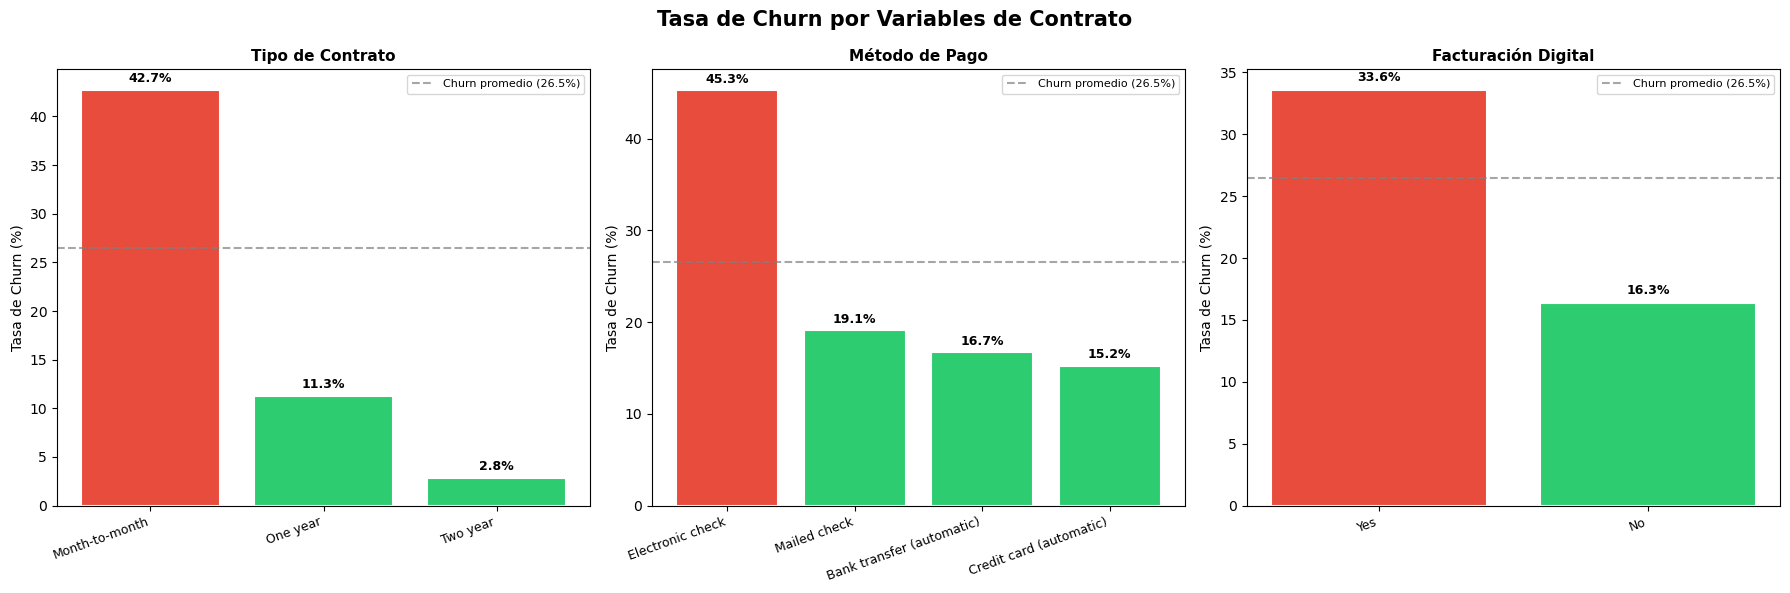


💡 HALLAZGOS CLAVE:
  → Contrato Mes a Mes: ~42% de churn vs ~11% anual vs ~3% bianual
  → Electronic Check: mayor churn entre métodos de pago
  → Facturación digital: levemente mayor churn


In [20]:
# --- ANÁLISIS: Variables Contractuales ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Tasa de Churn por Variables de Contrato", 
            fontsize=15, fontweight="bold")

plot_churn_rate("Contract", axes[0], "Tipo de Contrato")
plot_churn_rate("PaymentMethod", axes[1], "Método de Pago")
plot_churn_rate("PaperlessBilling", axes[2], "Facturación Digital")

plt.tight_layout()
plt.savefig("../visuals/04_churn_contrato.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n💡 HALLAZGOS CLAVE:")
print("  → Contrato Mes a Mes: ~42% de churn vs ~11% anual vs ~3% bianual")
print("  → Electronic Check: mayor churn entre métodos de pago")
print("  → Facturación digital: levemente mayor churn")

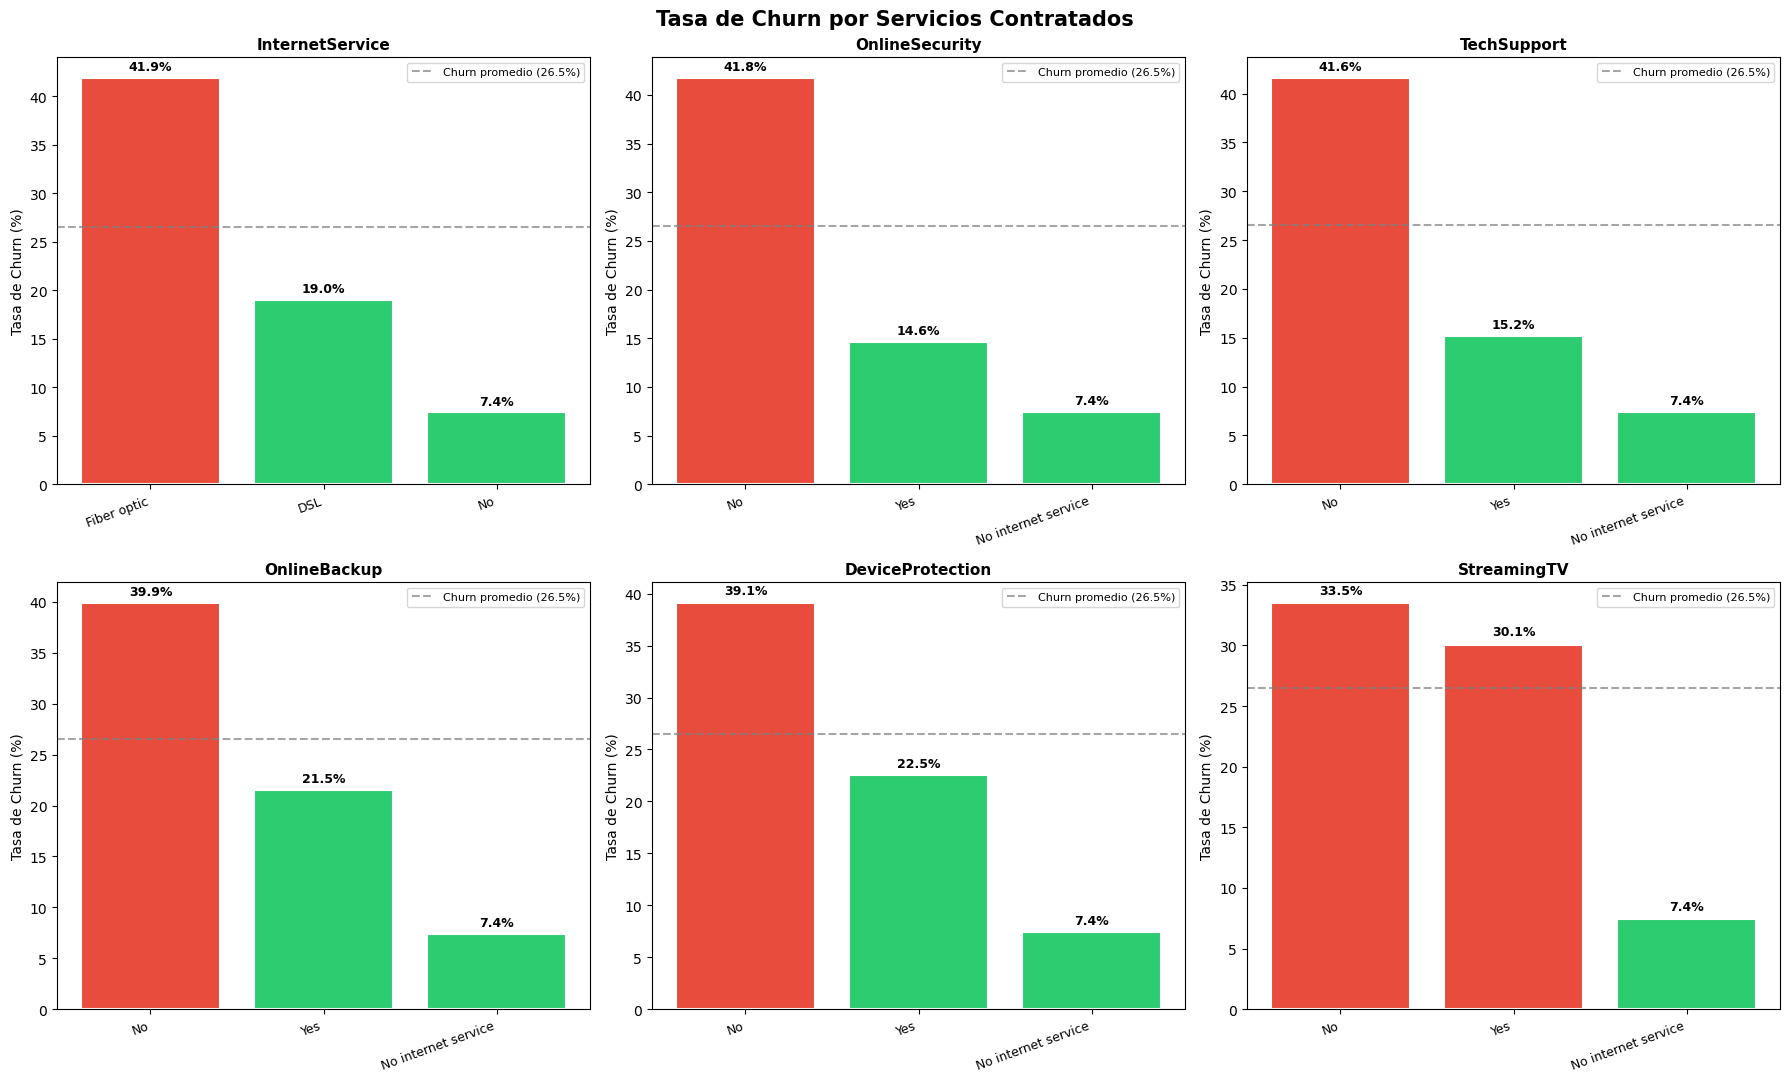


💡 HALLAZGOS CLAVE:
  → Fiber Optic: ~42% churn (¿problemas de calidad en el servicio o precio muy elevado?)
  → Sin Seguridad Online: ~41% churn vs 15% con seguridad
  → Sin Soporte Técnico: ~41% churn vs 15% con soporte


In [21]:
# --- ANÁLISIS: Variables de Servicios ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Tasa de Churn por Servicios Contratados", 
            fontsize=15, fontweight="bold")

servicios = ["InternetService", "OnlineSecurity", "TechSupport", 
            "OnlineBackup", "DeviceProtection", "StreamingTV"]

for i, servicio in enumerate(servicios):
    row, col = i // 3, i % 3
    plot_churn_rate(servicio, axes[row][col], servicio)

plt.tight_layout()
plt.savefig("../visuals/05_churn_servicios.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n💡 HALLAZGOS CLAVE:")
print("  → Fiber Optic: ~42% churn (¿problemas de calidad en el servicio o precio muy elevado?)")
print("  → Sin Seguridad Online: ~41% churn vs 15% con seguridad")
print("  → Sin Soporte Técnico: ~41% churn vs 15% con soporte")

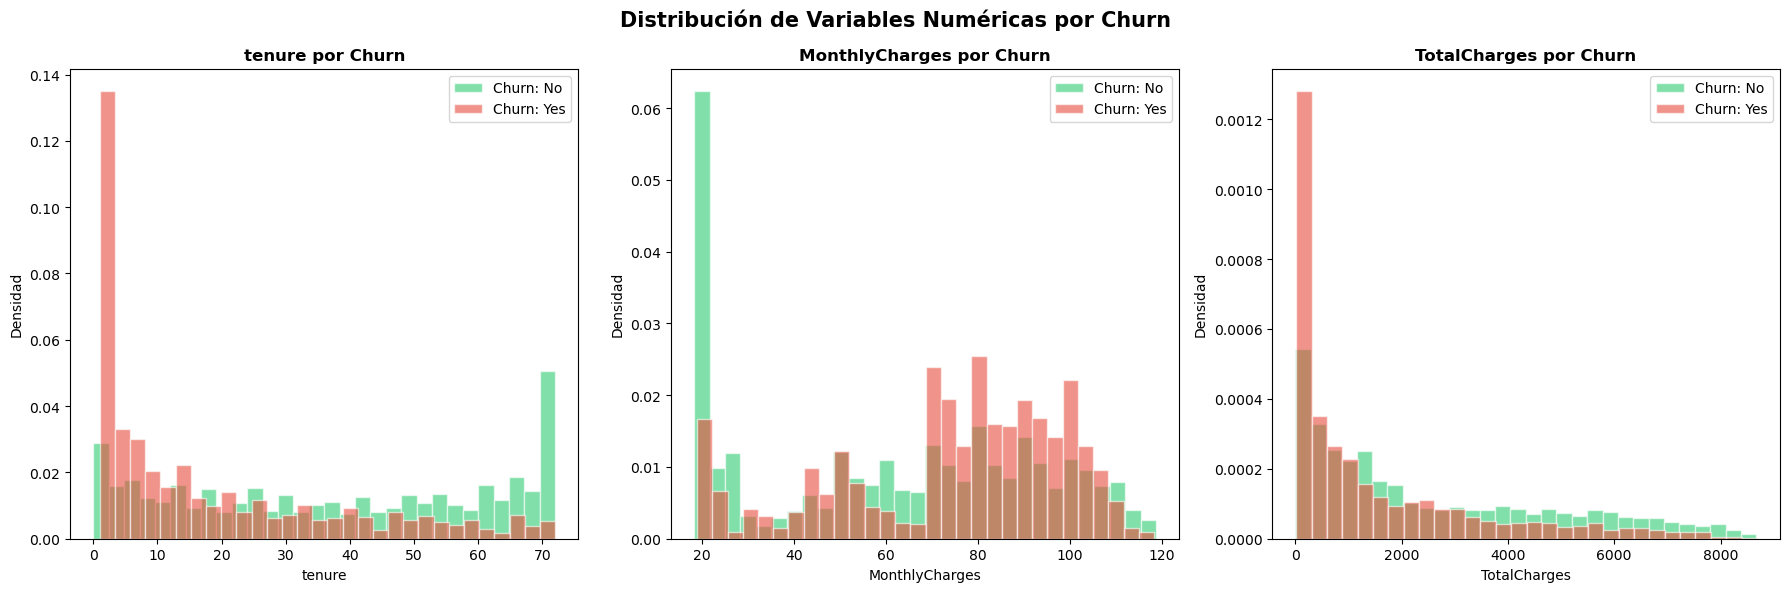


💡 HALLAZGOS CLAVE:
  → TENURE: Clientes con churn concentrados en primeros meses (0-20)
  → MONTHLY CHARGES: Clientes con churn tienen cargos mensuales más altos
  → TOTAL CHARGES: Clientes con churn acumularon menos (se van antes)


In [ ]:
# --- ANÁLISIS: Variables Numéricas vs Churn ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Distribución de Variables Numéricas por Churn", 
            fontsize=15, fontweight="bold")

vars_num = ["tenure", "MonthlyCharges", "TotalCharges"]
colores = {"No": "#2ecc71", "Yes": "#e74c3c"}

for i, var in enumerate(vars_num):
    for churn_val, color in colores.items():
        data = df[df["Churn"] == churn_val][var]
        axes[i].hist(data, bins=30, alpha=0.6, 
                    color=color, label=f"Churn: {churn_val}",
                    edgecolor="white", density=True)
    
    axes[i].set_title(f"{var} por Churn", fontweight="bold")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Densidad")
    axes[i].legend()

plt.tight_layout()
plt.savefig("../visuals/06_numericas_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n💡 HALLAZGOS CLAVE:")
print("  → TENURE: Clientes con churn concentrados en primeros meses (0-20)")
print("  → MONTHLY CHARGES: Clientes con churn tienen cargos mensuales más altos")
print("  → TOTAL CHARGES: Clientes con churn acumularon menos (se van antes)")

=== MATRIZ DE CORRELACIONES ===


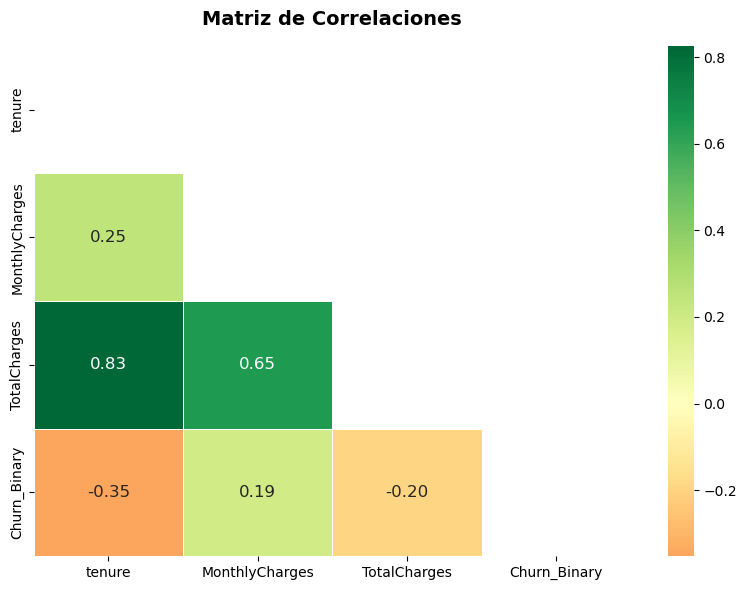


💡 INTERPRETACIÓN DEL MAPA DE CALOR:
  → tenure vs Churn_Binary: -0.35 (correlación NEGATIVA)
     → A mayor antigüedad, MENOR probabilidad de churn
  → MonthlyCharges vs Churn_Binary: +0.19 (correlación POSITIVA)
     → A mayor cargo mensual, MAYOR probabilidad de churn
  → TotalCharges vs tenure: +0.83 (alta correlación esperada)
     → Multicolinealidad a considerar en modelos futuros


In [26]:
# --- ANÁLISIS MULTIVARIADO: Mapa de Calor de Correlaciones ---
print("=== MATRIZ DE CORRELACIONES ===")

# Seleccionar variables numéricas + target binario
vars_corr = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_Binary"]
corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Solo triángulo inferior

sns.heatmap(corr_matrix, 
            annot=True,           # Mostrar valores
            fmt=".2f",            # 2 decimales
            cmap="RdYlGn",        # Rojo=negativo, Verde=positivo
            center=0,             # Centro en 0
            mask=mask,
            ax=ax,
            linewidths=0.5,
            annot_kws={"size": 12})

ax.set_title("Matriz de Correlaciones", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("../visuals/07_correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n💡 INTERPRETACIÓN DEL MAPA DE CALOR:")
print("  → tenure vs Churn_Binary: -0.35 (correlación NEGATIVA)")
print("     → A mayor antigüedad, MENOR probabilidad de churn")
print("  → MonthlyCharges vs Churn_Binary: +0.19 (correlación POSITIVA)")  
print("     → A mayor cargo mensual, MAYOR probabilidad de churn")
print("  → TotalCharges vs tenure: +0.83 (alta correlación esperada)")
print("     → Multicolinealidad a considerar en modelos futuros")

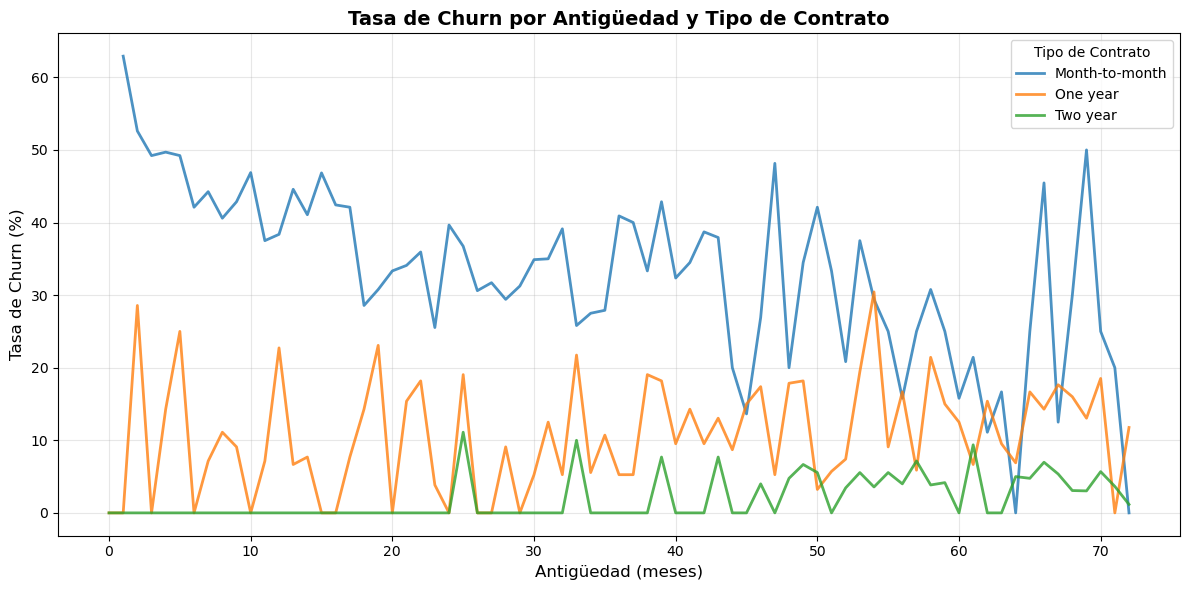


💡 INSIGHT PROFUNDO:
  → Contratos mes a mes: churn MUY alto en primeros 6 meses,
    luego se estabiliza. La ventana crítica de retención es el
    PRIMER TRIMESTRE de vida del cliente.


In [28]:
# --- ANÁLISIS PROFUNDO: Interacción entre variables ---
# Tipo de contrato × Tenure × Churn

fig, ax = plt.subplots(figsize=(12, 6))

for contrato in df["Contract"].unique():
    subset = df[df["Contract"] == contrato]
    # Calcular tasa de churn por mes de tenure
    churn_por_tenure = subset.groupby("tenure")["Churn_Binary"].mean() * 100
    ax.plot(churn_por_tenure.index, churn_por_tenure.values, 
            label=contrato, linewidth=2, alpha=0.8)

ax.set_xlabel("Antigüedad (meses)", fontsize=12)
ax.set_ylabel("Tasa de Churn (%)", fontsize=12)
ax.set_title("Tasa de Churn por Antigüedad y Tipo de Contrato", 
            fontsize=14, fontweight="bold")
ax.legend(title="Tipo de Contrato", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../visuals/08_churn_tenure_contrato.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n💡 INSIGHT PROFUNDO:")
print("  → Contratos mes a mes: churn MUY alto en primeros 6 meses,")
print("    luego se estabiliza. La ventana crítica de retención es el")  
print("    PRIMER TRIMESTRE de vida del cliente.")